In [1]:
## Objective: To find insights from E-Commerce dataset.

In [2]:
## Data Understanding
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick ## mtick means Matplotlib ticker. It is used to control how numbers appear on your chart's axes.
import calendar
import numpy as np

# Read excel dataset and convert it to dataframe
data = pd.read_excel("./ecommerce.xlsx")
df = pd.DataFrame(data)

print(df.head(4))
print()
print(df.info())
print()
print(df.describe())

   order_id           order_date  customer_id product_category region  \
0     10001  2022-01-01 00:00:00         1102           Beauty  South   
1     10002  2022-02-01 00:00:00         1435         Clothing  South   
2     10003  2022-03-01 00:00:00         1860           Beauty   East   
3     10004  2022-04-01 00:00:00         1270      Electronics   West   

   quantity  unit_price  discount payment_method  delivery_days  \
0         7      373.65      0.28         Wallet             10   
1         7       47.74      0.09           Card              6   
2         3      311.28      0.31            COD              6   
3         5      524.47      0.02         Wallet              6   

   customer_rating  revenue  
0              4.7  1883.20  
1              3.9   304.10  
2              2.5   644.35  
3              1.6  2569.90  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  D

In [3]:
## Data Quality

### Missing Value Check 
print(df.isnull().sum())
print()

### Duplicates Check
print(f"Order Id: {df['order_id'].duplicated().sum()}")  # <-> Primary/Unique Key
print(f"Order Date: {df['order_date'].duplicated().sum()}")
print(f"Customer Id: {df['customer_id'].duplicated().sum()}") # Customers can reoccur to buy same/other products
print(f"Product Category: {df['product_category'].duplicated().sum()}")
print(f"Region: {df['region'].duplicated().sum()}")
print(f"Quantity: {df['quantity'].duplicated().sum()}")
print(f"Unit Price: {df['unit_price'].duplicated().sum()}")
print(f"Discount: {df['discount'].duplicated().sum()}")
print(f"Payment Method: {df['payment_method'].duplicated().sum()}")
print(f"Delivery Days: {df['delivery_days'].duplicated().sum()}")
print(f"Customer Rating: {df['customer_rating'].duplicated().sum()}")
print(f"Revenue: {df['revenue'].duplicated().sum()}")
print()

### No Invalid Values

### Data Inconsistencies
df["order_date"] = pd.to_datetime(df["order_date"],errors="coerce") # YYYY-MM-DD; coerce means if you find a value that you can't understand as a date, don't give me an error. Convert it to a missing value (NaT)
print(df["order_date"].head(5))

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Order Id: 0
Order Date: 0
Customer Id: 4011
Product Category: 4996
Region: 4996
Quantity: 4993
Unit Price: 212
Discount: 4964
Payment Method: 4997
Delivery Days: 4989
Customer Rating: 4959
Revenue: 60

0   2022-01-01
1   2022-02-01
2   2022-03-01
3   2022-04-01
4   2022-05-01
Name: order_date, dtype: datetime64[ns]


In [4]:
## Data Transformation/Preparation
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day

df["discount_amount"] = (df["quantity"] * df["unit_price"] * df["discount"])

df["delivery_category"] = pd.cut(  # pd.cut() is used to divide numerical values into groups 
    df["delivery_days"],
    bins=[0,3,7,float("inf")],
    labels=["Fast","Average","Slow"]
)
df["rating_category"] = pd.cut(
    df["customer_rating"],
    bins=[0,1,2,3,4,5],
    labels=["Very Poor","Poor","Average","Good","Excellent"]
)
df["discount_percent"] = df["discount"] * 100

In [5]:
## EDA (Exploratory Data Analysis) means understand and explore data.
### Dataset structure
print(df.shape)
print()
print(df.info())
print()
print(df.columns)
print()

### Missing values
print(df.isnull().sum())
print()
print(df.isnull().mean() * 100)
print()

### Duplicate records
print(df.duplicated().sum())
print()

### Numerical variable analysis
print(df["discount"].describe())
print()

### Categorical analysis
print(df["product_category"].value_counts())
print()
print(df["region"].value_counts(normalize=True) * 100)
print()
print(df["payment_method"].value_counts())
print()
print(df["delivery_category"].value_counts())
print()
print(df["rating_category"].value_counts())

(5000, 19)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           5000 non-null   int64         
 1   order_date         5000 non-null   datetime64[ns]
 2   customer_id        5000 non-null   int64         
 3   product_category   5000 non-null   object        
 4   region             5000 non-null   object        
 5   quantity           5000 non-null   int64         
 6   unit_price         5000 non-null   float64       
 7   discount           5000 non-null   float64       
 8   payment_method     5000 non-null   object        
 9   delivery_days      5000 non-null   int64         
 10  customer_rating    5000 non-null   float64       
 11  revenue            5000 non-null   float64       
 12  year               5000 non-null   int32         
 13  month              5000 non-null   int32         
 

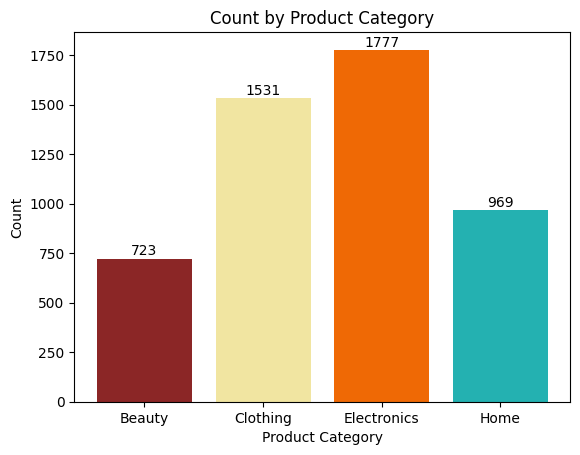

In [6]:
## Univariate Analysis - me ek column ko analyze karte hain (mainly Histogram, Bar Chart, Pie Chart, Box Plot, Count Plot, KDE/Density Plot) se represent hote hai. Even count, sum, mean, median of a column comes under univariate.

### Product Category Count (NOTE: This does not show sales, revenue, profit, population, etc. It only shows the number of records/rows associated with each product category.)
product_cat_count = df.groupby("product_category").agg({"product_category":"count"})
colors = ["#8B2626","#F1E5A1","#EF6905","#24B1B1"]

bar1 = plt.bar(product_cat_count.index,product_cat_count.product_category,color=colors)

plt.bar_label(
    bar1,
    labels=[f"{x:.0f}" for x in product_cat_count.product_category],
    padding=0.3
)

plt.title("Count by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

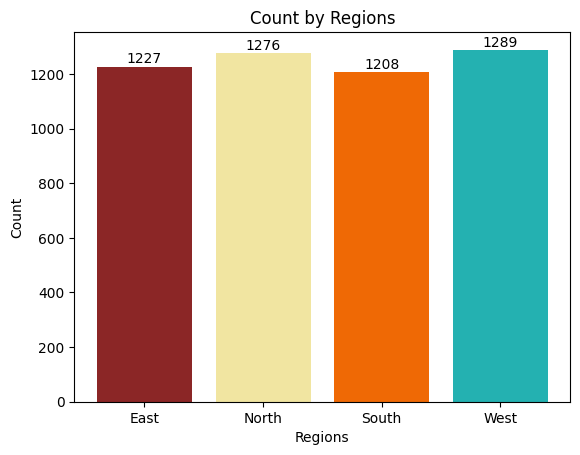

In [7]:
### Region Count (NOTE: This does not show sales, revenue, profit, population, etc. It only shows the number of records/rows associated with each region.)
region_count = df.groupby("region").agg({"region":"count"})

bar2 = plt.bar(region_count.index,region_count.region,color=colors)

plt.bar_label(bar2,labels=[f"{x:.0f}" for x in region_count.region],padding=0.3)

plt.title("Count by Regions")
plt.xlabel("Regions")
plt.ylabel("Count")
plt.show()

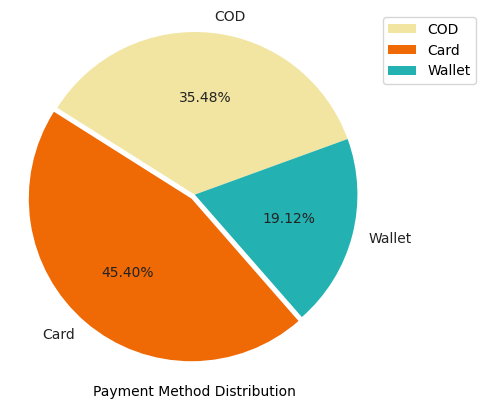

In [9]:
### Payment Method Count (NOTE: This does not show sales, revenue, profit, population, etc. It only shows the number of records/rows associated with each Payment Method.)
payment_method_count = df.groupby("payment_method").agg({"payment_method":"count"})
exp = [0,0.035,0] # explode
textprop = {"color":"#222222"} # text color

plt.pie(payment_method_count.payment_method,colors=colors[1:4],explode=exp,labels=payment_method_count.index,autopct="%.2f%%",startangle=20,radius=1.1,textprops=textprop)
plt.xlabel("Payment Method Distribution")
plt.legend(loc=1,bbox_to_anchor=(1.28,1))
plt.show()

In [10]:
### Numerical Column Analysis
print(df[["quantity","unit_price","discount","delivery_days","customer_rating","revenue"]].describe())

          quantity   unit_price     discount  delivery_days  customer_rating  \
count  5000.000000  5000.000000  5000.000000    5000.000000      5000.000000   
mean      4.044800   308.418774     0.179984       6.118800         2.973980   
std       2.020398   169.259369     0.101404       3.153264         1.157722   
min       1.000000    15.150000     0.000000       1.000000         1.000000   
25%       2.000000   161.895000     0.090000       3.000000         2.000000   
50%       4.000000   309.890000     0.180000       6.000000         3.000000   
75%       6.000000   455.557500     0.270000       9.000000         4.000000   
max       7.000000   599.960000     0.350000      11.000000         5.000000   

           revenue  
count  5000.000000  
mean   1021.955148  
std     825.584219  
min      11.210000  
25%     354.527500  
50%     796.650000  
75%    1515.690000  
max    4119.330000  


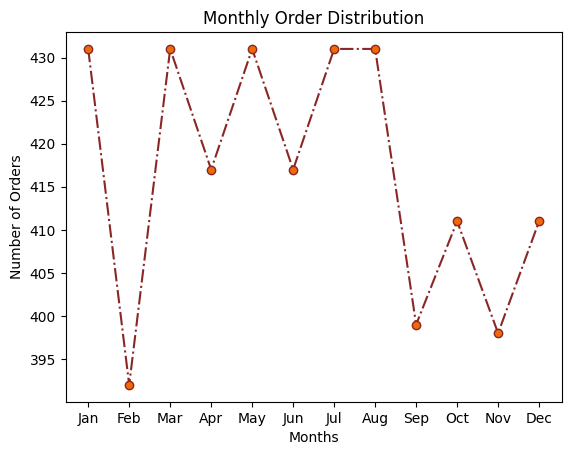

In [11]:
### Month Wise Distribution (NOTE: This does not show sales, revenue, profit, population, etc. It only shows the number of records/rows associated with each Month.)
month_wise_dist = df.groupby("month").agg({"month":"count"})
month_wise_dist.index = month_wise_dist.index.map(lambda x: calendar.month_name[x][0:3]) # Changing month number to month name

plt.plot(month_wise_dist.index,month_wise_dist.month,marker="o",ls="-.",c=colors[0],mfc=colors[2]) # Line Plot

plt.title("Monthly Order Distribution")
plt.xlabel("Months")
plt.ylabel("Number of Orders")
plt.show()

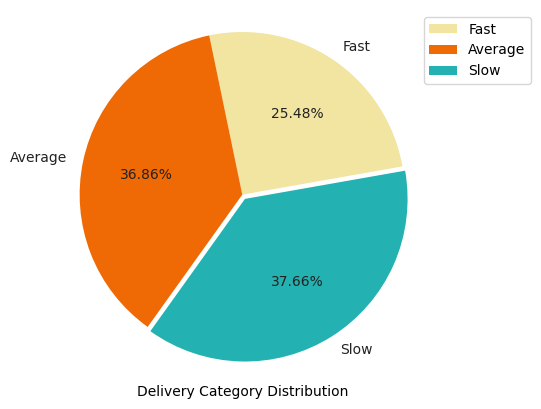

In [12]:
### Delivery Category Dist (NOTE: This does not show sales, revenue, profit, population, etc. It only shows the number of records/rows associated with each Delivery Categroy.)
delivery_cat_dist = df.groupby("delivery_category",observed=False).agg({"delivery_category":"count"})
exp2 = [0,0,0.034] # Explode

plt.pie(delivery_cat_dist.delivery_category,labels= delivery_cat_dist.index,explode=exp2,radius=1.1,autopct="%.2f%%",colors=colors[1:4],startangle=10,textprops=textprop)
plt.xlabel("Delivery Category Distribution")
plt.legend(loc=1,bbox_to_anchor=(1.3,1))
plt.show()

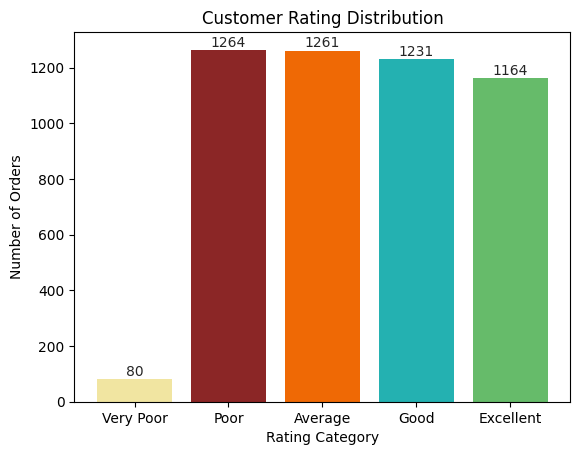

In [13]:
### Rating Category Distribution (NOTE: This does not show sales, revenue, profit, population, etc. It only shows the number of records/rows associated with each Rating Category)
rating_cat_dist = df.groupby("rating_category", observed=False).agg({"rating_category":"count"})
colors2 = ["#F1E5A1","#8B2626","#EF6905","#24B1B1","#66BB6A"]

bar4 = plt.bar(rating_cat_dist.index,rating_cat_dist.rating_category,color=colors2)

plt.bar_label(bar4,labels=[x for x in rating_cat_dist.rating_category],padding=0.2,color="#252525")

plt.title("Customer Rating Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Orders")
plt.show()

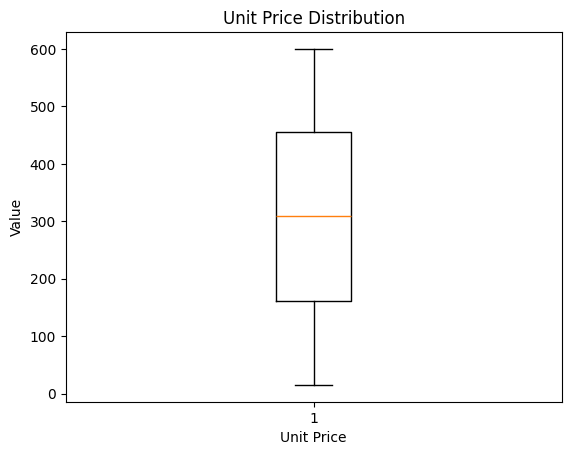

In [14]:
### Unit Price Distribution
plt.boxplot(df["unit_price"])
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Value")
plt.show()

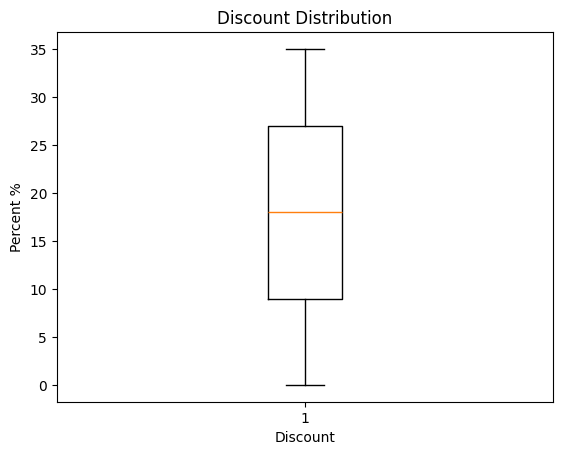

In [15]:
### Discount Distribution
plt.boxplot(df["discount_percent"])
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Percent %")
plt.show()

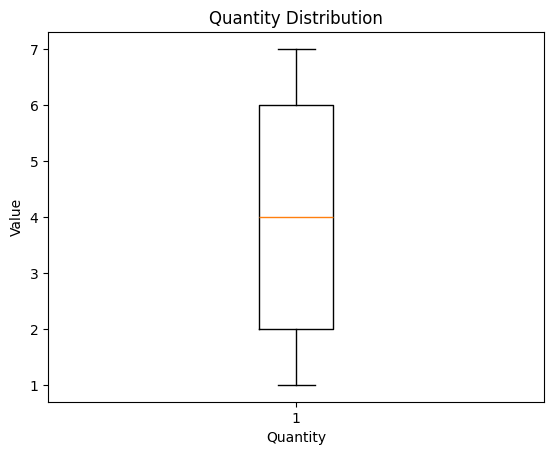

In [16]:
### Quantity Distribution
plt.boxplot(df["quantity"])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Value")
plt.show()

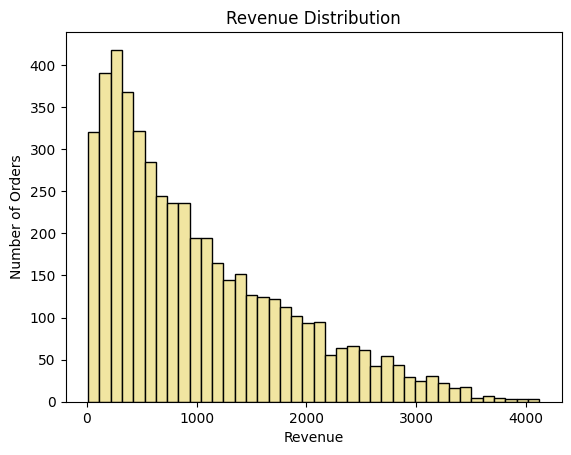

In [17]:
### Revenue Distribution
plt.hist(df["revenue"],bins=40,color=colors[1],edgecolor="black")
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")
plt.show()

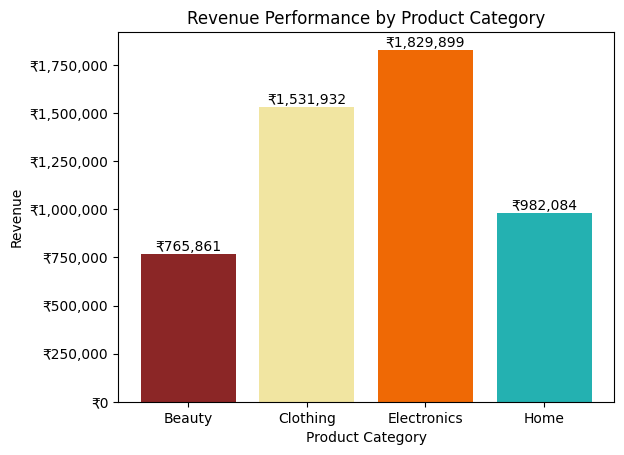

In [18]:
## Bivariate Analysis - me 2 column ke relationship ko analyze karte hain (mainly Scatter Plot, Bar Chart, Box Plot, Violin Plot, Line Chart, Area Chart, Heatmap, Grouped Bar Chart, Stacked Bar Chart, Bubble Chart) se represent hote hai.

### Product Category & Revenue
groupProductRevenue = df.groupby("product_category").agg({"revenue":"sum"})

# Bar Chart
bar5 = plt.bar(groupProductRevenue.index,groupProductRevenue.revenue,color=colors)

# Formatting y-axis numerical labels
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}")) ## gca: Get Current Axes; yaxis: I want to change the y-axis; set_major_formatter: tells Matplotlib how to display the numbers; mtick.StrMethodFormatter: specify a formatting pattern   

# Bar chart labels
plt.bar_label(bar5,labels=[f"₹{x:,.0f}" for x in groupProductRevenue.revenue],padding=0.3)

# Tilte, X-Y axis labels
plt.title("Revenue Performance by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

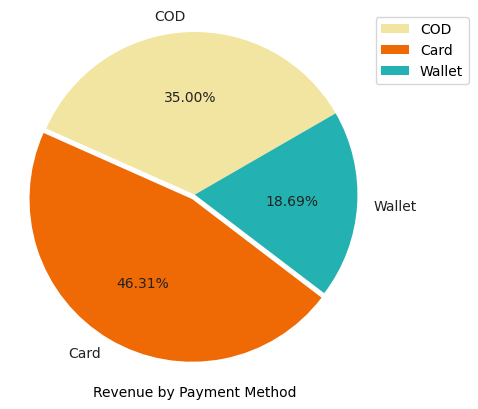

In [19]:
### Payment Method & Revenue
groupRegionProduct = df.groupby("payment_method").agg({"revenue":"sum"})

# Pie Chart
plt.pie(groupRegionProduct.revenue,labels=groupRegionProduct.index,explode=exp,autopct="%.2f%%",colors=colors[1:4],startangle=30,radius=1.1,textprops={"color":"#222222"})

# X-axis label
plt.xlabel("Revenue by Payment Method")
plt.legend(loc=1,bbox_to_anchor=(1.26,1))
plt.show()

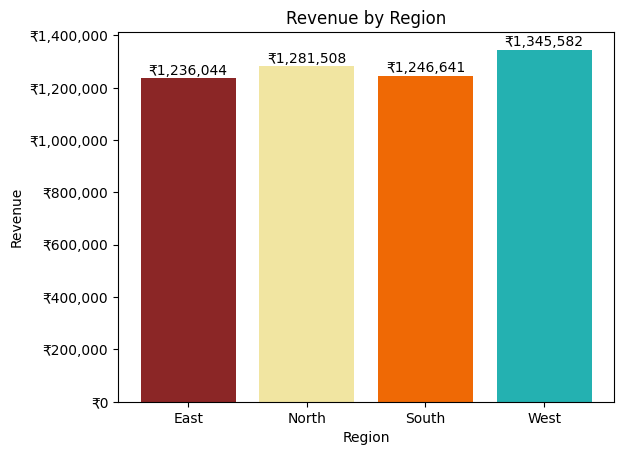

In [20]:
### Region & Revenue
groupRegionRevenue = df.groupby("region").agg({"revenue":"sum"})

# Bar Chart
bar6 = plt.bar(groupRegionRevenue.index,groupRegionRevenue.revenue,color=colors)

# Formatting y-axis numerical labels
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

# Bar chart labels
plt.bar_label(bar6,labels=[f"₹{x:,.0f}" for x in groupRegionRevenue.revenue],padding=0.6)

# Tilte, X-Y axis labels
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

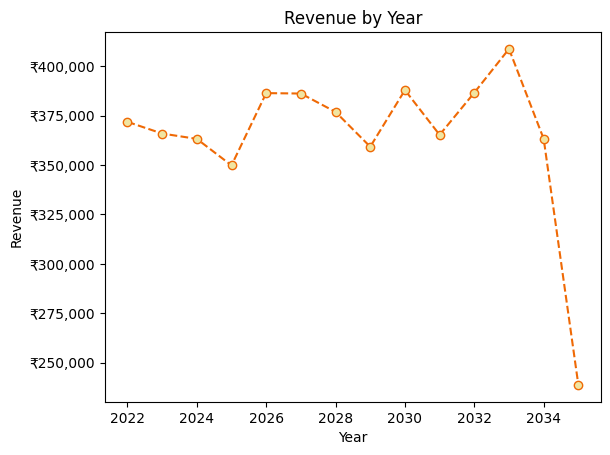

In [21]:
### Year & Revenue
year_revenue = df.groupby("year").agg({"revenue":"sum"})

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.plot(year_revenue.index,year_revenue.revenue,marker="o",c=colors2[2],ls="--",mfc=colors2[0])

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

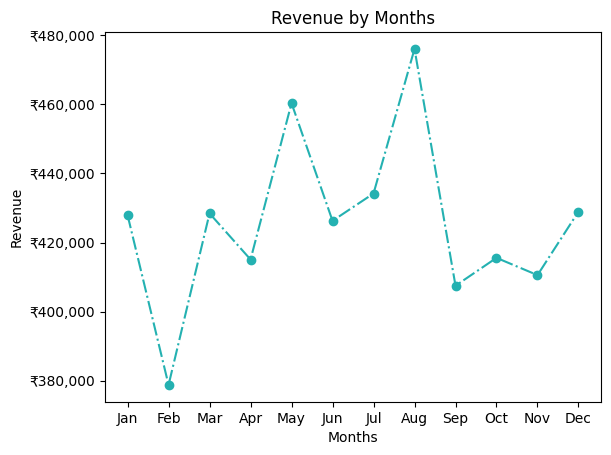

In [22]:
### Month & Revenue
month_revenue = df.groupby("month").agg({"revenue":"sum"})
month_revenue.index = month_revenue.index.map(lambda x: calendar.month_name[x][0:3]) # Changing month number to month name

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.plot(month_revenue.index,month_revenue.revenue,marker="o",ls="-.",c=colors2[3])

plt.title("Revenue by Months")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.show()

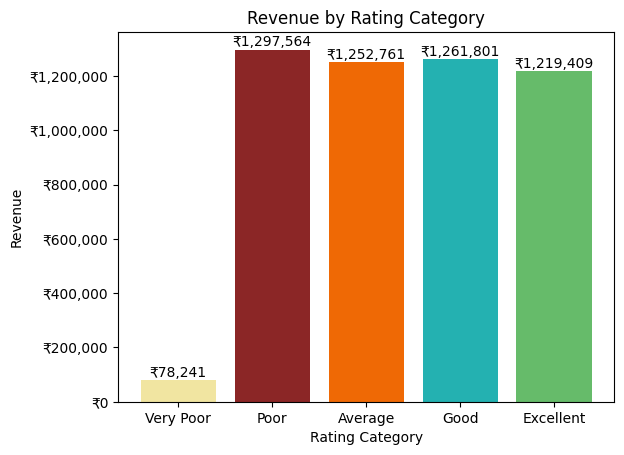

In [23]:
### Rating Category & Revenue 
rating_cat_revenue = df.groupby("rating_category",observed=False).agg({"revenue":"sum"})

bar7 = plt.bar(rating_cat_revenue.index,rating_cat_revenue.revenue,color=colors2)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.bar_label(bar7,labels=[f"₹{x:,.0f}" for x in rating_cat_revenue.revenue],padding=0.4)

plt.title("Revenue by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Revenue")
plt.show()

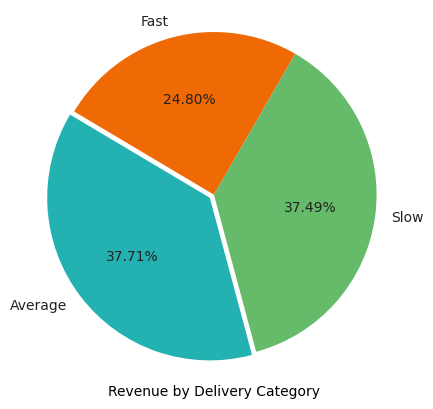

In [24]:
### Delivery Category & Revenue
delivery_cat_revenue = df.groupby("delivery_category",observed=False).agg({"revenue":"sum"})

plt.pie(delivery_cat_revenue.revenue,labels=delivery_cat_revenue.index,explode=exp,colors=colors2[2:5],autopct="%.2f%%",textprops=textprop,radius=1.1,startangle=60)

plt.xlabel("Revenue by Delivery Category")
plt.show()

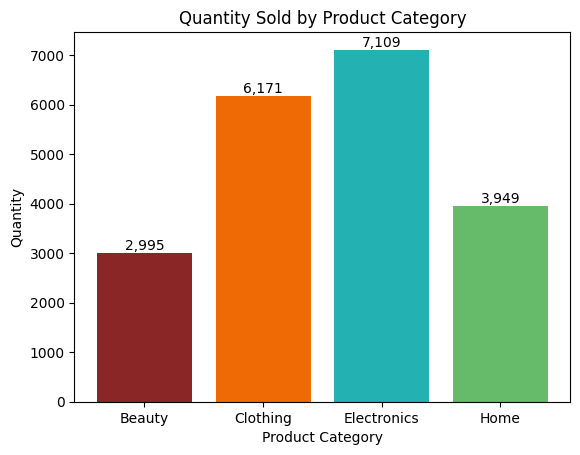

In [25]:
### Product Category & Qauntity
prod_cat_quant = df.groupby("product_category").agg({"quantity":"sum"})

bar8 = plt.bar(prod_cat_quant.index,prod_cat_quant.quantity,color=colors2[1:5])

plt.bar_label(bar8,labels=[f"{x:,.0f}" for x in prod_cat_quant.quantity],padding=0.3)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.show()

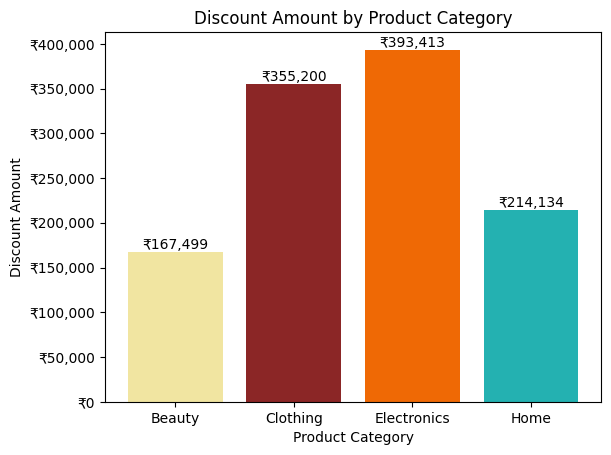

In [26]:
### Product Category & Discount Amount
prod_cat_discount = df.groupby("product_category").agg({"discount_amount":"sum"})

bar9 = plt.bar(prod_cat_discount.index,prod_cat_discount.discount_amount,color=colors2)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.bar_label(bar9,labels=[f"₹{x:,.0f}" for x in prod_cat_discount.discount_amount],padding=0.3)

plt.title("Discount Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Discount Amount")
plt.show()

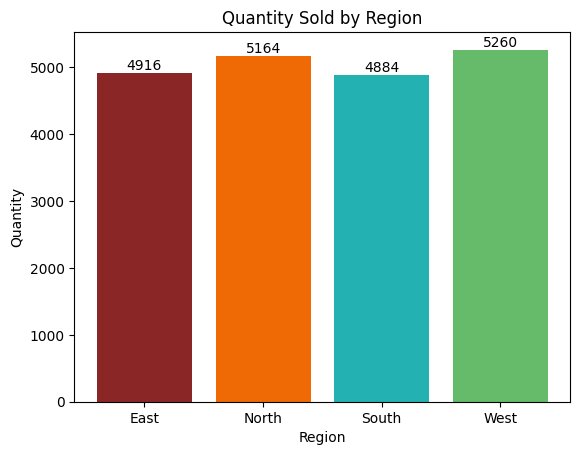

In [27]:
## Region & Quantity
region_quantity = df.groupby("region").agg({"quantity":"sum"})

bar10 = plt.bar(region_quantity.index,region_quantity.quantity,color=colors2[1:5])

plt.bar_label(bar10,labels=[x for x in region_quantity.quantity],padding=0.2)
plt.title("Quantity Sold by Region")
plt.xlabel("Region")
plt.ylabel("Quantity")
plt.show()

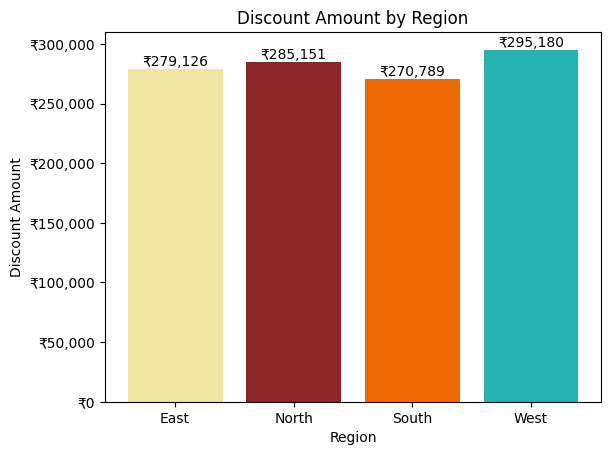

In [29]:
## Region & Discount Amount
region_discount = df.groupby("region").agg({"discount_amount":"sum"})

bar11 = plt.bar(region_discount.index,region_discount.discount_amount,color=colors2[0:5])

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.bar_label(bar11,labels=[f"₹{x:,.0f}" for x in region_discount.discount_amount],padding=0.2)

plt.title("Discount Amount by Region")
plt.xlabel("Region")
plt.ylabel("Discount Amount")
plt.show()

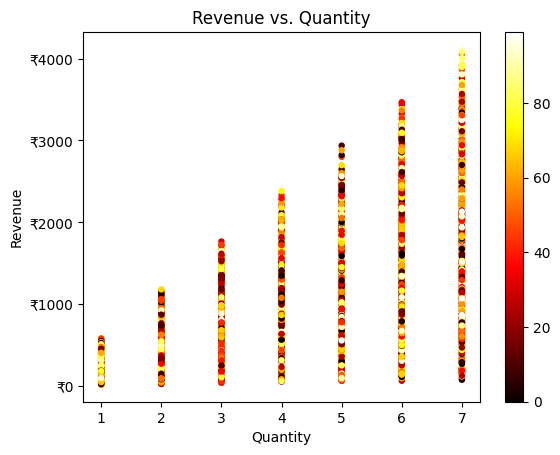

In [30]:
## Quantity & Revenue (Relationship: The higher the Quantity; The more is the Revenue; Hence Positive Relationship)
colors3 = np.random.randint(0,100,5000)

plt.scatter(df["quantity"],df["revenue"],marker="o",c=colors3,cmap="hot",s=13)
plt.colorbar()

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:.0f}"))

plt.title("Revenue vs. Quantity")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

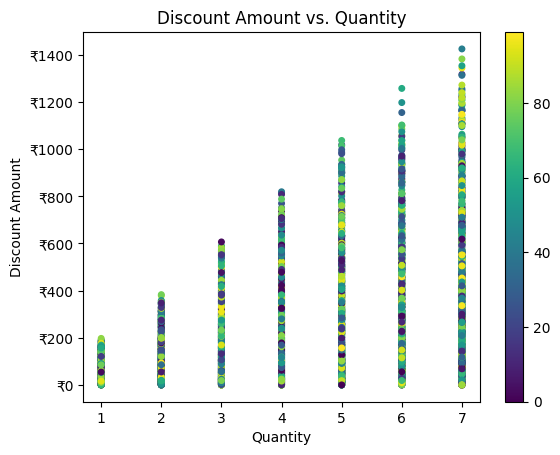

In [31]:
## Quantity & Discount (Relationship: The higher the Quantity; The more is the Discount Amount; Hence Positive Relationship)
plt.scatter(df["quantity"],df["discount_amount"],c=colors3,s=16)
plt.colorbar()

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:.0f}"))

plt.title("Discount Amount vs. Quantity")
plt.xlabel("Quantity")
plt.ylabel("Discount Amount")
plt.show()

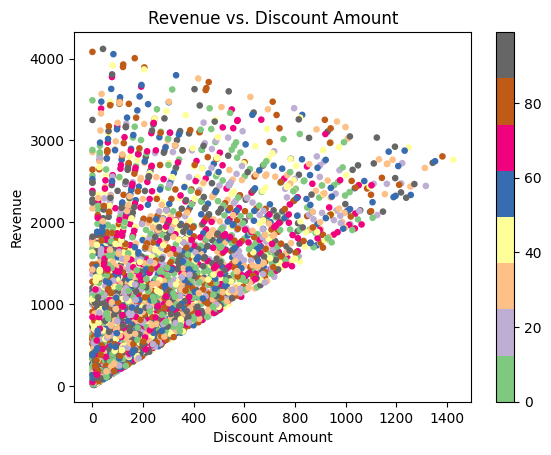

In [32]:
## Discount Amount & Revenue (Positive relationship but the points are widely scattered, so the relationship is not very strong) 
plt.scatter(df["discount_amount"],df["revenue"],c=colors3,cmap="Accent",s=14)

plt.colorbar()
plt.title("Revenue vs. Discount Amount")
plt.xlabel("Discount Amount")
plt.ylabel("Revenue")
plt.show()

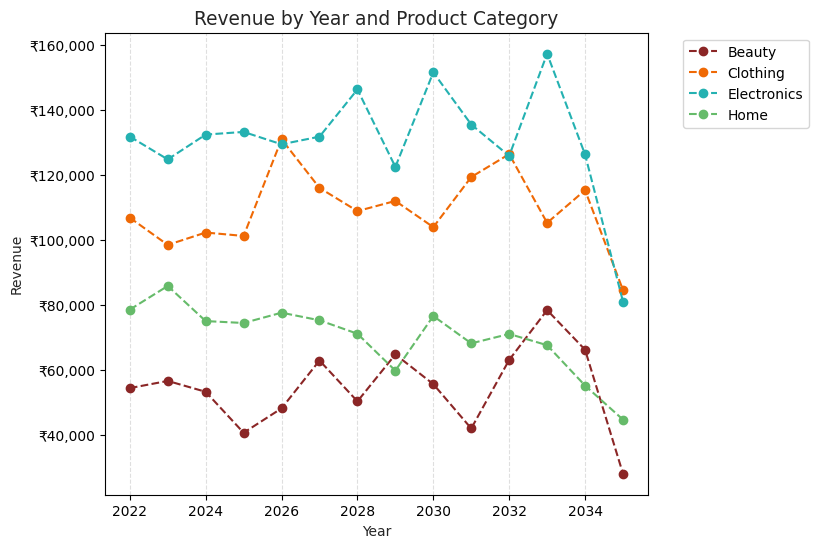

In [33]:
## Multivariate Analysis - me 3 ya usse jyda column ke relationship ko analyze karte hain (mainly Multi-Line Chart, Multi-Bar Chart, Scatter Plot, Box Plot, Heatmap) se represent hote hai.

### Year & Revenue Based On Product Category
### Pivot Table data ko group karke uska summary banati hai, taaki comparison easily kar sakein.
year_revenue_prodcat = pd.pivot_table(df,index="year",columns="product_category",values="revenue",aggfunc="sum") #index=x-axis, values=y-axis, columns=group_column_name, aggfunc by default value is mean. 

year_revenue_prodcat.plot(kind="line",marker="o",figsize=(7, 6),color=colors2[1:5],fontsize=10,ls="--") 

plt.grid(axis="x",linestyle="--",alpha=0.4)  # Grid Lines

plt.legend(loc=1,bbox_to_anchor=(1.31,1))

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
plt.title("Revenue by Year and Product Category",fontsize=13.4,color="#252525")
plt.xlabel("Year",color="#252525")
plt.ylabel("Revenue",color="#252525")
plt.show()

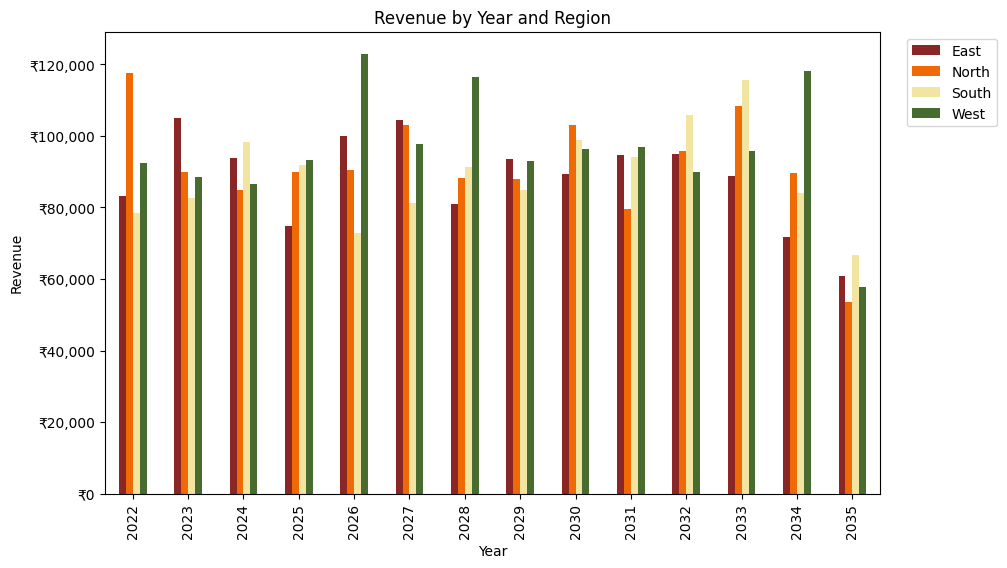

In [33]:
### Year & Revenue Based On Region
colors4 = ["#8B2626","#EF6905","#F1E5A1","#486C2F"]

year_revenue_region = pd.pivot_table(df,index="year",columns="region",values="revenue",aggfunc="sum")

year_revenue_region.plot(kind="bar",figsize=(10,6),xlabel="Year",ylabel="Revenue",color=colors4)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
plt.title("Revenue by Year and Region")
plt.legend(loc=1,bbox_to_anchor=(1.16,1))
plt.show()

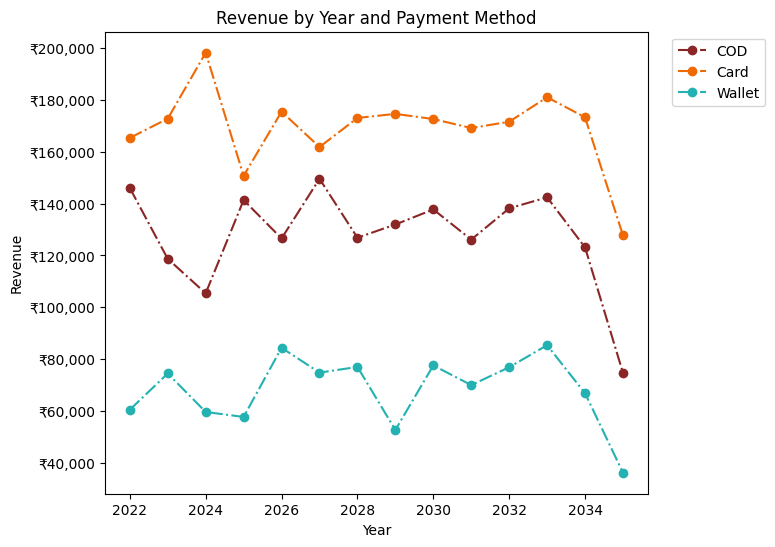

In [34]:
### Year & Revenue Based On Payment Method
year_revenue_paymtd = pd.pivot_table(df,index="year",columns="payment_method",values="revenue",aggfunc="sum")

year_revenue_paymtd.plot(kind="line",marker="o",figsize=(7, 6),color=colors2[1:5],fontsize=10,ls="-.",xlabel="Year",ylabel="Revenue")

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
plt.title("Revenue by Year and Payment Method")
plt.legend(loc=1,bbox_to_anchor=(1.23,1))
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_44944\3323342787.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  year_revenue_delcat = pd.pivot_table(df,index="year",columns="delivery_category",values="revenue",aggfunc="sum")


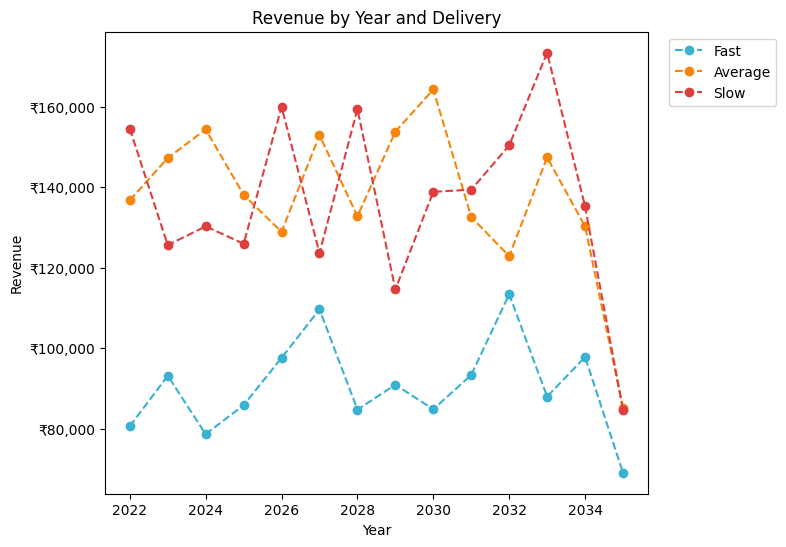

In [35]:
### Year & Revenue Based On Delivery Category
colors5 = ["#39B1D1","#F6850C","#DE3E3E","#007979","#E0C375","#F5788B"]

year_revenue_delcat = pd.pivot_table(df,index="year",columns="delivery_category",values="revenue",aggfunc="sum")

year_revenue_delcat.plot(kind="line",marker="o",figsize=(7, 6),color=colors5[0:3],fontsize=10,ls="--",xlabel="Year",ylabel="Revenue")

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
plt.title("Revenue by Year and Delivery")
plt.legend(loc=1,bbox_to_anchor=(1.25,1))
plt.show()

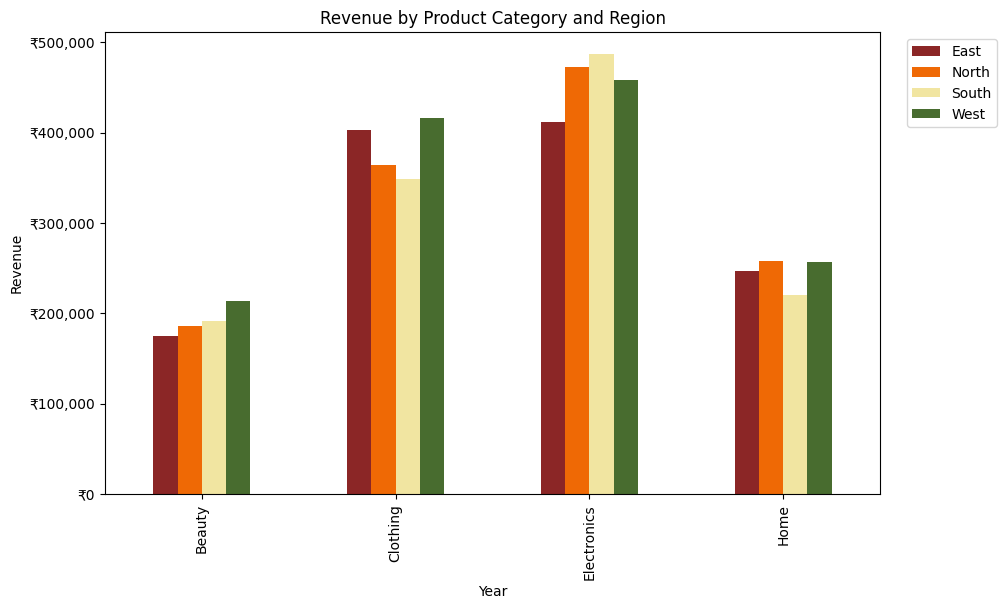

In [36]:
### Product Category and Revenue Based On Region
prod_rev_reg = pd.pivot_table(df,index="product_category",columns="region",values="revenue",aggfunc="sum")

prod_rev_reg.plot(kind="bar",figsize=(10,6),xlabel="Year",ylabel="Revenue",color=colors4)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
plt.title("Revenue by Product Category and Region")
plt.legend(loc=1,bbox_to_anchor=(1.16,1))
plt.show()

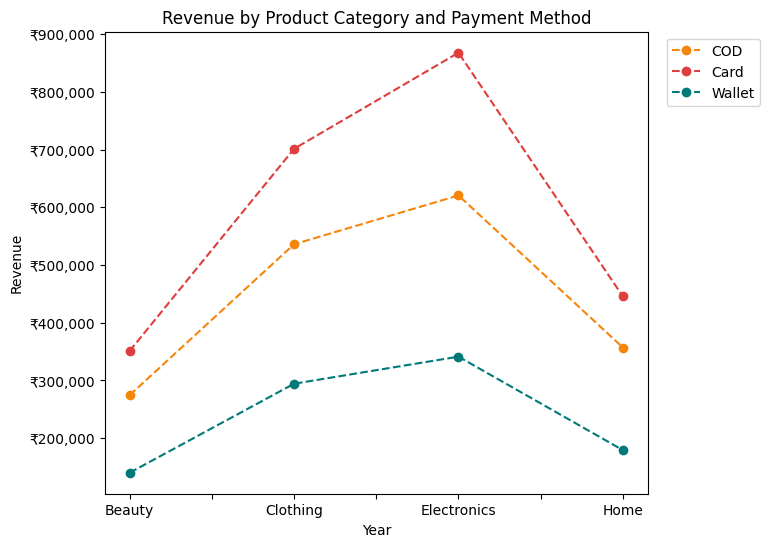

In [37]:
### Product Category and Revenue Based On Payment Method
prod_rev_paymethd = pd.pivot_table(df,index="product_category",columns="payment_method",values="revenue",aggfunc="sum")

prod_rev_paymethd.plot(kind="line",marker="o",figsize=(7, 6),color=colors5[1:5],fontsize=10,ls="--",xlabel="Year",ylabel="Revenue")

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
plt.title("Revenue by Product Category and Payment Method")
plt.legend(loc=1,bbox_to_anchor=(1.22,1))
plt.show()

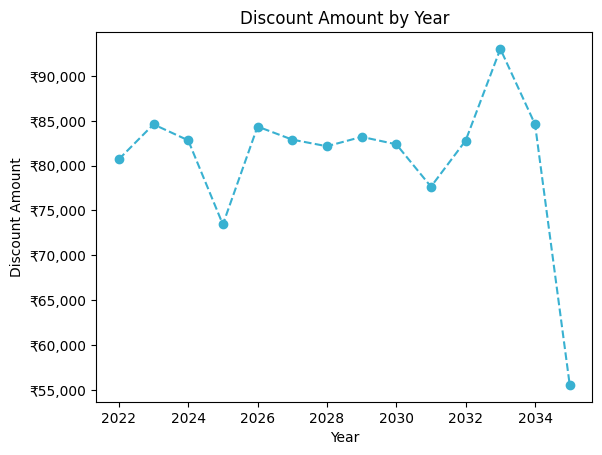

In [38]:
### Discount Amount by Year
total_dis_rev = df.groupby("year").agg({"discount_amount":"sum"})

plt.plot(total_dis_rev.index,total_dis_rev.discount_amount,marker="o",ls="--",color=colors5[0])

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.title("Discount Amount by Year")
plt.xlabel("Year")
plt.ylabel("Discount Amount")
plt.show()

In [39]:
## Correlation Analysis

"""
+1	means Perfect positive correlation
+0.7 to +0.99 means	Strong positive correlation
+0.3 to +0.69 means	Moderate positive correlation
0 means	No linear correlation
−0.3 to −0.69 means Moderate negative correlation
−0.7 to −0.99 means Strong negative correlation
−1 means Perfect negative correlation
"""

correlation = df.corr(numeric_only=True)

print("Revenue Correlation With Other Variables:")
print(correlation["revenue"].sort_values(ascending=False))
print()

print("Quantity Correlation With Other Variables:")
print(correlation["quantity"].sort_values(ascending=False))
print()

print("Discount Amount Correlation With Other Variables:")
print(correlation["discount_amount"].sort_values(ascending=False))
print()

Revenue Correlation With Other Variables:
revenue             1.000000
unit_price          0.678032
quantity            0.623564
discount_amount     0.600011
customer_id         0.025499
month               0.021678
customer_rating     0.012446
order_id            0.009681
year                0.009001
day                 0.006088
delivery_days       0.005444
discount           -0.139296
discount_percent   -0.139296
Name: revenue, dtype: float64

Quantity Correlation With Other Variables:
quantity            1.000000
revenue             0.623564
discount_amount     0.467867
customer_id         0.023097
customer_rating     0.019168
unit_price          0.001498
year               -0.002604
order_id           -0.003368
discount           -0.004302
discount_percent   -0.004302
delivery_days      -0.008748
month              -0.015514
day                -0.018086
Name: quantity, dtype: float64

Discount Amount Correlation With Other Variables:
discount_amount     1.000000
revenue            

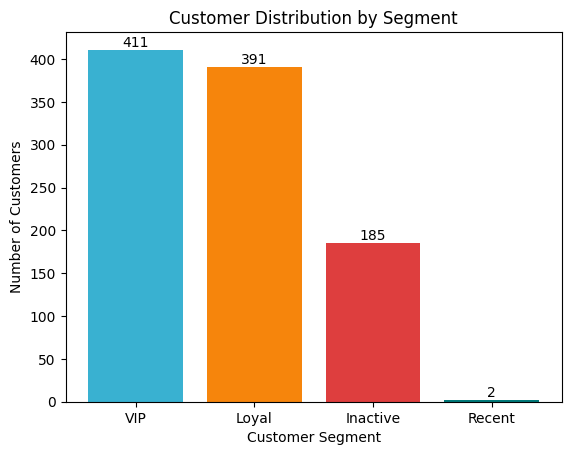

In [40]:
## Segmentation means dividing data into groups based on their purchasing behavior. A very common approach is RFM analysis: R — Recency: How recently did the customer purchase? F — Frequency: How often did the customer purchase? M — Monetary: How much money did the customer spend?
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1) # finds the latest order date in your dataset; Then adds one day

# Create the RFM table
rfm = df.groupby("customer_id").agg(
    Recency = ("order_date",lambda x: (snapshot_date - x.max()).days),
    Frequency = ("order_id","count"),
    Monetry = ("revenue","sum")
)

def segment_customer(row):
    if row["Frequency"] >= 5 and row["Monetry"] >= 5000:
        return "VIP"
    elif row["Frequency"] >= 3 and row["Monetry"] >= 2000:
        return "Loyal"
    elif row["Recency"] <= 30:
        return "Recent"
    else:
        return "Inactive"

rfm["Segment"] = rfm.apply(segment_customer,axis=1) # Apply segment_customer to every row.

rfm_segment_count = rfm["Segment"].value_counts()

bar12 = plt.bar(rfm_segment_count.index,rfm_segment_count,color=colors5)

plt.bar_label(bar12, [x for x in rfm_segment_count],padding=0.3)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

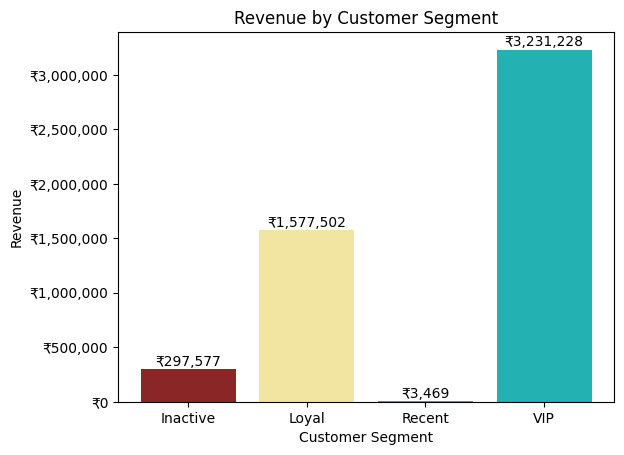

In [41]:
rfm_monetry_revenue = rfm.groupby("Segment").agg({"Monetry":"sum"})

bar13 = plt.bar(rfm_monetry_revenue.index,rfm_monetry_revenue.Monetry,color=colors)

plt.bar_label(bar13,[f"₹{x:,.0f}" for x in rfm_monetry_revenue.Monetry],padding=0.4)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.show()

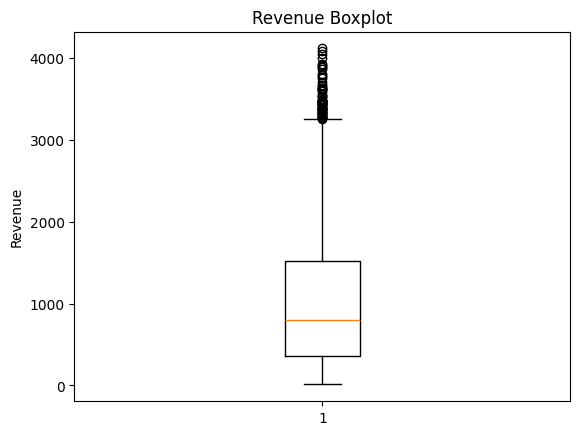

In [42]:
## Outlier Analysis

# Revenue Outlier
plt.boxplot(df["revenue"].dropna())
plt.title("Revenue Boxplot")

plt.ylabel("Revenue")
plt.show()

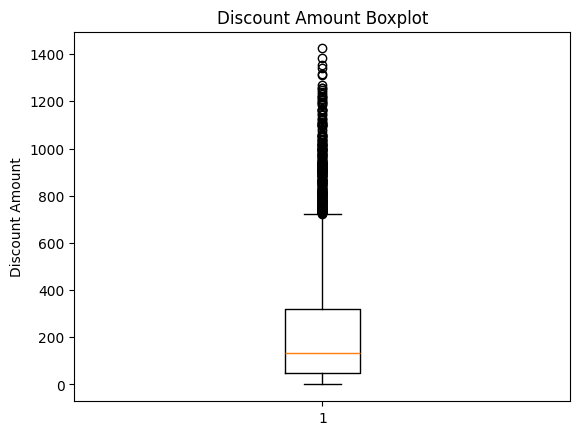

In [43]:
# Discount Outlier
plt.boxplot(df["discount_amount"].dropna())
plt.title("Discount Amount Boxplot")
plt.ylabel("Discount Amount")
plt.show()

In [44]:
## Business Insights & Recommendations

### 1) Card and COD are the most preferred payment methods and major revenue contributors; Card recorded its highest usage in 2024 at ₹8.8 Lakh, while COD reached its highest usage in 2027 at ₹6 Lakh; increase COD availability and offer incentives on prepaid payments to balance customer convenience with digital-payment adoption.
### 2) Most deliveries are slow to average and contribute significantly to revenue; Slow delivery generated the highest revenue in 2033 at ₹1.8 Lakh, while Average delivery recorded the highest revenue in 2030 at ₹1.63 Lakh; improving logistics and delivery efficiency could enhance customer satisfaction and retention.
### 3) Customer satisfaction is mixed; prioritize improvements in delivery, product quality, and customer service to increase positive ratings.
### 4) The highest frequency appears around 200–500 revenue, indicating this is the common revenue range per order; As revenue increases, the number of orders steadily decreases; Focus on upselling and cross-selling to increase average order value.
### 5) Electronics generated the highest revenue at ₹18.30 Lakh and recorded the highest product sales, making it the top-performing category; Clothing followed with ₹15.30 Lakh in revenue; Prioritize high-demand electronics, maintain sufficient inventory, and use cross-selling opportunities to further increase sales and revenue.
### 6) West Region generated the highest revenue of ₹13.45 Lakh; North Region followed with revenue of ₹12.81 Lakh; West generated approximately ₹64,074 more revenue than North. Replicate successful strategies from the West to strengthen performance across other regions.
### 7) Revenue peaked at over ₹4 lakh in mid-2032, highlighting a period of strong sales performance and an opportunity to replicate successful strategies.
### 8) August leads monthly revenue, followed by May; Strengthen seasonal campaigns and inventory planning around these high-performing months to maximize revenue opportunities.
### 9) Poor-rated customers contribute the highest revenue of ₹12.97 Lakh, while Very Poor-rated customers generate only ₹0.78 Lakh; Improving customer experience can help reduce dissatisfaction and strengthen long-term revenue potential.
### 10) The West region recorded the highest discount amount of ₹2.95 Lakh followed by the North region with ₹2.85 Lakh; The West region also recorded the highest quantity sold, indicating strong sales activity in the region.
### 11) Higher Quantity Sold leads to higher Revenue, indicating a positive relationship between Quantity and Revenue.
### 12) Higher Quantity Sold is associated with a higher Discount Amount, indicating a positive relationship between Quantity and Discount Amount.
### 13) Electronics recorded its highest revenue in 2033 at ₹1.56 Lakh, Clothing in 2026 at ₹1.30 Lakh, Home in 2023 at ₹85,000, and Beauty in 2033 at ₹80,000; Increase promotional efforts for Clothing and Home to improve their revenue performance.
### 14) Discount recorded its highest value in 2033 at ₹95,000; optimize discount strategies toward high-performing products to maximize revenue while maintaining profitability.
### 15) VIP customers recorded the highest customer count at 411, generating ₹32.31 Lakh in revenue, followed by Loyal customers with 391 customers and ₹15.78 Lakh in revenue. Inactive customers accounted for 185 customers and ₹2.98 Lakh in revenue, while Recent customers had only 2 customers and ₹3,469 in revenue; prioritize retention strategies for VIP and Loyal customers while implementing targeted re-engagement campaigns to convert Inactive and Recent customers into repeat buyers.


In [50]:
## KPI (Key Performance Indicator)

# Total Order
totalOrder = df["order_id"].count()
print(f"Total Orders: {totalOrder}")

# Total Revenue
totalRevenue = df["revenue"].sum()
print(f"Total Revenue: ₹{totalRevenue:,.0f}")

# Total Discount
totalDiscount = df["discount_amount"].sum()
print(f"Total Discount Offered: ₹{totalDiscount:,.0f}")

# Total Quantity Sold
totalQuantitySold = df["quantity"].sum()
print(f"Total Quantity Sold: {totalQuantitySold}")

# Total Products Category
totalProductsCategory = df["product_category"].nunique()
print(f"Total Products Category: {totalProductsCategory}")

# Average Delivery Days
averageDeliveryDay = df["delivery_days"].mean()
print(f"Average Delivery Days: {averageDeliveryDay:.0f}")

# Average Customer Rating
averageCustomerRating = df["customer_rating"].mean()
print(f"Average Customer Rating: {averageCustomerRating:.0f}")


Total Orders: 5000
Total Revenue: ₹5,109,776
Total Discount Offered: ₹1,130,246
Total Quantity Sold: 20224
Total Products Category: 4
Average Delivery Days: 6
Average Customer Rating: 3
